# DE capacity factors: simple approximation vs. MaStR-weighted

`de_capacity_factor_current_fleet` (this hub's primary DE capacity-factor
product) weights PECD's zone/technology-level capacity factors by MaStR's
real, unit-level installed-capacity data -- accurate, but it only works
where a MaStR-equivalent registry exists, i.e. Germany. This page asks: how
far do we get with a *much* simpler approximation that needs no per-unit
fleet data at all -- just PECD's own capacity factors plus a couple of
publicly known, fixed weights?

**This is exploratory only.** Nothing here becomes a new hub data asset --
see `energy-data-hub/docs/pecd_data_availability.md`. The point of building
it this simply is that, unlike MaStR, it has no Germany-only ceiling: the
same fixed weights below could eventually run against every PECD country in
`pecd_wind_onshore_europe_capacity_factors` / `..._offshore_...` (already
downloaded full-Europe, see that same doc) to get a first-cut capacity
factor for countries that will never have a MaStR-style unit registry.

## The weights used, explicitly

**Solar** -- PECD's `nuts_0` (true country-level) product already gives one
series per technology (`60` industrial rooftop, `61` residential rooftop,
`62` utility fixed-tilt, `63` utility tracking) with no region aggregation
needed. The open question is only how to blend these four into one number.
Fixed weights below, held constant across the whole 2015-2025 history (not
MaStR, but not equal-weighted either -- equal weights would hand
utility-tracking a quarter of the mix, when it's close to absent in
Germany):

| technology | weight | basis |
|---|---|---|
| `62` utility fixed-tilt | 31% | ~40 of ~120 GW total DE PV capacity was ground-mounted at end of 2025 (pv magazine, citing BSW-Solar/BNetzA), minus tracking's sliver |
| `63` utility tracking | 2% | only 23 of Germany's 300 largest solar parks use tracking (rare, uneconomical at today's module prices) |
| `61` residential rooftop | 39% | 2025 additions: 5.2 GW private roof vs. 3.7 GW large commercial roof (BSW-Solar) -> ~58/42 split of the ~67% rooftop share |
| `60` industrial/commercial rooftop | 28% | the remaining ~42% of the rooftop share |

**Wind onshore/offshore** -- PECD has no `nuts_0` product for wind at all
(confirmed against the live CDS API, see
`pecd_wind_onshore_country_capacity_factor`'s own docstring), only
zone-level (`PEON`/`PEOF`). The simple approximation here: weight each
zone by its physical area (from PECD's own rasterized zone mask, the same
file `edh.region_geo.fractional_zone_weights` uses for MaStR unit
assignment), not by installed capacity -- i.e. assume turbines are spread
uniformly per km² rather than concentrated by real siting. Zones PECD
never modeled (100% NaN capacity factor -- true for 3 of DE's 6 PEOF
offshore zones) are dropped and the remaining zones' weights renormalized
to sum to 1, rather than silently letting pandas' default `skipna` sum
treat a dropped zone's weight as zero without redistributing it (that bug,
caught before writing this page, is exactly why offshore's first pass
looked far worse than it actually is).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from insights.paths import hub_file

COMPLEX_COLOR = "#2a78d6"  # de_capacity_factor_current_fleet -- MaStR-weighted, this hub's real product
SIMPLE_COLOR = "#eb6834"  # this page's fixed-weight approximation -- no MaStR involved

SOLAR_WEIGHTS = {"62": 0.31, "63": 0.02, "61": 0.39, "60": 0.28}  # see table above

## Solar: fixed technology-mix weights

In [2]:
assert abs(sum(SOLAR_WEIGHTS.values()) - 1.0) < 1e-9
print(pd.Series(SOLAR_WEIGHTS, name="weight").rename_axis("pecd_technology"))

solar_tech = pd.read_parquet(hub_file("pecd", "pecd_solar_country_capacity_factors.parquet"))
solar_simple = sum(solar_tech[tech] * weight for tech, weight in SOLAR_WEIGHTS.items()).rename("simple")

pecd_technology
62    0.31
63    0.02
61    0.39
60    0.28
Name: weight, dtype: float64


## Wind onshore/offshore: area weights from PECD's own zone mask

In [3]:
def zone_area_weights(mask_file, cf_columns, zone_prefix: str = "DE") -> pd.Series:
    """Relative land/sea area per zone: sum of each 0.25-degree cell's
    fractional zone coverage, weighted by cos(latitude) (cells narrow
    towards the poles in the longitude direction; latitude degrees don't
    change) -- restricted to `cf_columns` (i.e. zones PECD actually modeled,
    dropping the all-NaN ones) and renormalized to sum to 1 over those."""
    ds = xr.open_dataset(mask_file)
    zones = [z for z in cf_columns if z in ds["region"].values]
    mask_values = ds["mask"].sel(region=zones).values  # (zone, lat, lon)
    lat_weight = np.cos(np.radians(ds["latitude"].values))[None, :, None]
    ds.close()

    area = pd.Series((mask_values * lat_weight).sum(axis=(1, 2)), index=zones)
    return area / area.sum()


def area_weighted_zone_mean(cf: pd.DataFrame, mask_file) -> tuple[pd.Series, pd.Series]:
    """Area-weighted mean across whichever of `cf`'s zone columns PECD
    actually modeled (all-NaN columns excluded from both the mean and the
    weight renormalization -- see module docstring)."""
    modeled = cf.columns[cf.notna().any()]
    weights = zone_area_weights(mask_file, modeled)
    return (cf[weights.index] * weights).sum(axis=1), weights


onshore_zone_cf = pd.read_parquet(hub_file("pecd", "pecd_wind_onshore_capacity_factors.parquet"))
offshore_zone_cf = pd.read_parquet(hub_file("pecd", "pecd_wind_offshore_capacity_factors.parquet"))

onshore_simple, onshore_weights = area_weighted_zone_mean(onshore_zone_cf, hub_file("pecd", "peon_region_mask.nc"))
offshore_simple, offshore_weights = area_weighted_zone_mean(offshore_zone_cf, hub_file("pecd", "peof_region_mask.nc"))

print("Onshore PEON zone area weights (all 7 DE zones modeled):")
print(onshore_weights.round(3))
print(f"\nOffshore PEOF zone area weights ({len(offshore_weights)} of {offshore_zone_cf.shape[1]} DE zones modeled -- "
      f"{sorted(set(offshore_zone_cf.columns) - set(offshore_weights.index))} are 100% NaN, excluded):")
print(offshore_weights.round(3))

Onshore PEON zone area weights (all 7 DE zones modeled):
DE01    0.177
DE02    0.161
DE03    0.098
DE04    0.144
DE05    0.122
DE06    0.102
DE07    0.196
dtype: float64

Offshore PEOF zone area weights (3 of 6 DE zones modeled -- ['DE013_OFF', 'DE014_OFF', 'DE015_OFF'] are 100% NaN, excluded):
DE011_OFF    0.415
DE012_OFF    0.210
DE02_OFF     0.375
dtype: float32


## Comparison against `de_capacity_factor_current_fleet`

In [4]:
complex_cf = pd.read_parquet(hub_file("pecd", "de_capacity_factor_current_fleet.parquet"))

SERIES = {
    "solar": (solar_simple, complex_cf["capacity_factor_solar"]),
    "wind_onshore": (onshore_simple, complex_cf["capacity_factor_wind_onshore"]),
    "wind_offshore": (offshore_simple, complex_cf["capacity_factor_wind_offshore"]),
}


def error_stats(simple: pd.Series, complex_: pd.Series) -> dict:
    df = pd.concat([simple.rename("simple"), complex_.rename("complex")], axis=1, sort=False).dropna()
    err = df["simple"] - df["complex"]
    return {
        "n_hours": len(df),
        "mean_simple": df["simple"].mean(),
        "mean_complex": df["complex"].mean(),
        "corr": df["simple"].corr(df["complex"]),
        "bias_pp": err.mean() * 100,
        "mae_pp": err.abs().mean() * 100,
        "rmse_pp": (err**2).mean() ** 0.5 * 100,
    }


stats = pd.DataFrame({tech: error_stats(simple, complex_) for tech, (simple, complex_) in SERIES.items()}).T
print(stats.round(4))

               n_hours  mean_simple  mean_complex    corr  bias_pp  mae_pp  \
solar          96432.0       0.1109        0.1112  0.9993  -0.0331  0.3018   
wind_onshore   96432.0       0.2282        0.2254  0.9750   0.2765  3.1607   
wind_offshore  96432.0       0.4240        0.4137  0.9770   1.0251  4.7338   

               rmse_pp  
solar           0.6308  
wind_onshore    4.3667  
wind_offshore   6.1050  


## Monthly capacity factor, full history, per technology

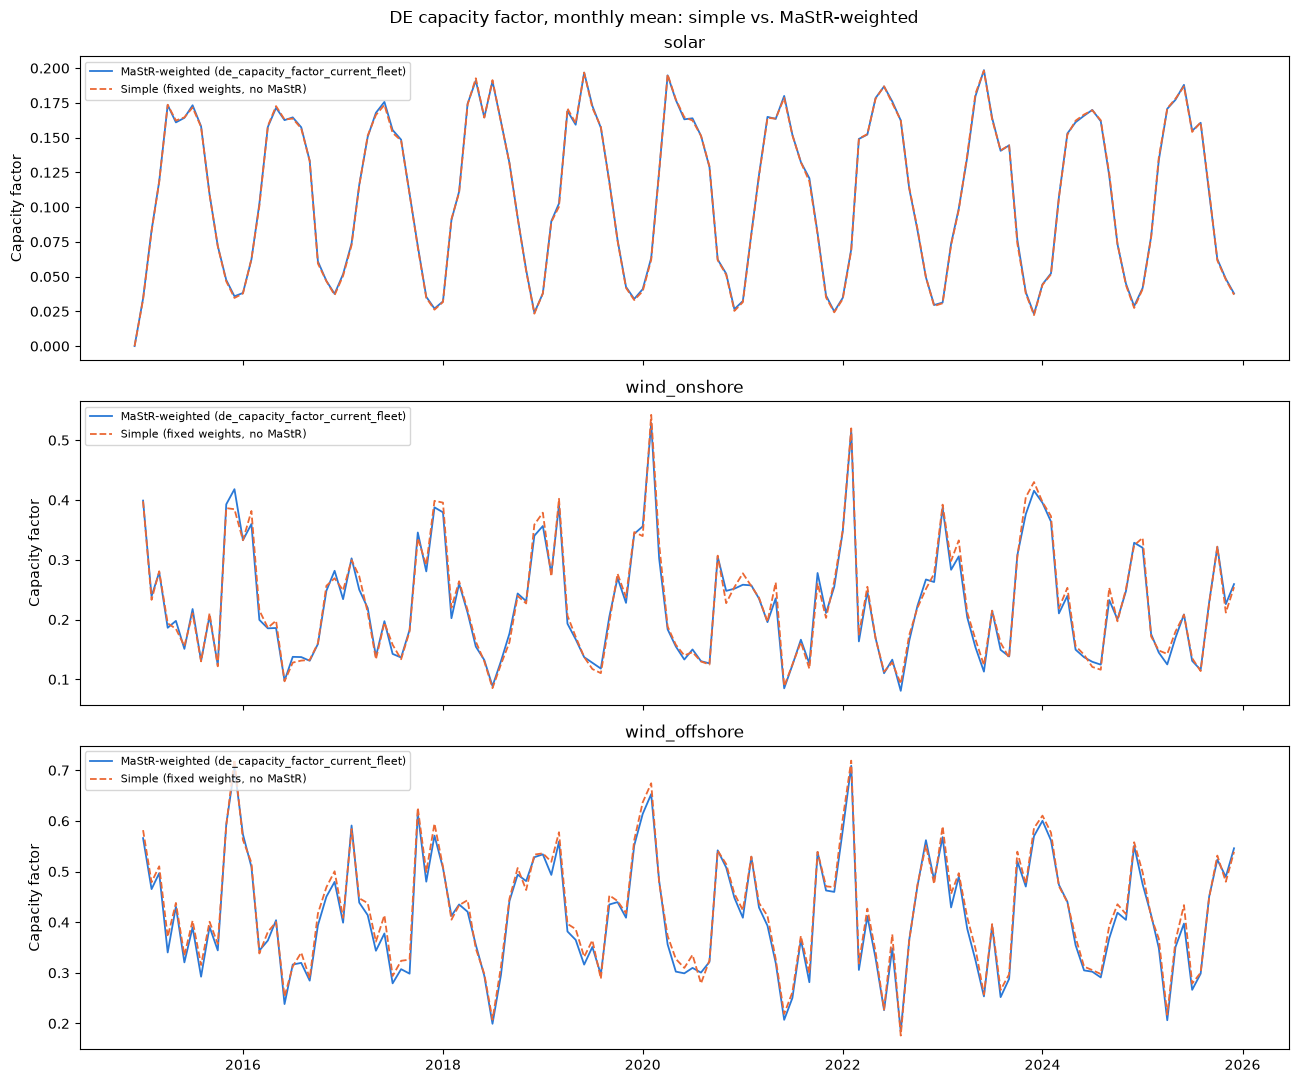

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
for ax, (tech, (simple, complex_)) in zip(axes, SERIES.items()):
    df = pd.concat([simple.rename("simple"), complex_.rename("complex")], axis=1, sort=False).dropna()
    monthly = df.resample("MS").mean()
    ax.plot(monthly.index, monthly["complex"], label="MaStR-weighted (de_capacity_factor_current_fleet)", color=COMPLEX_COLOR, linewidth=1.3)
    ax.plot(monthly.index, monthly["simple"], label="Simple (fixed weights, no MaStR)", color=SIMPLE_COLOR, linewidth=1.3, linestyle="--")
    ax.set_ylabel("Capacity factor")
    ax.set_title(tech)
    ax.legend(loc="upper left", fontsize=8)
fig.suptitle("DE capacity factor, monthly mean: simple vs. MaStR-weighted")
fig.tight_layout()
plt.show()

## Annual mean, per technology

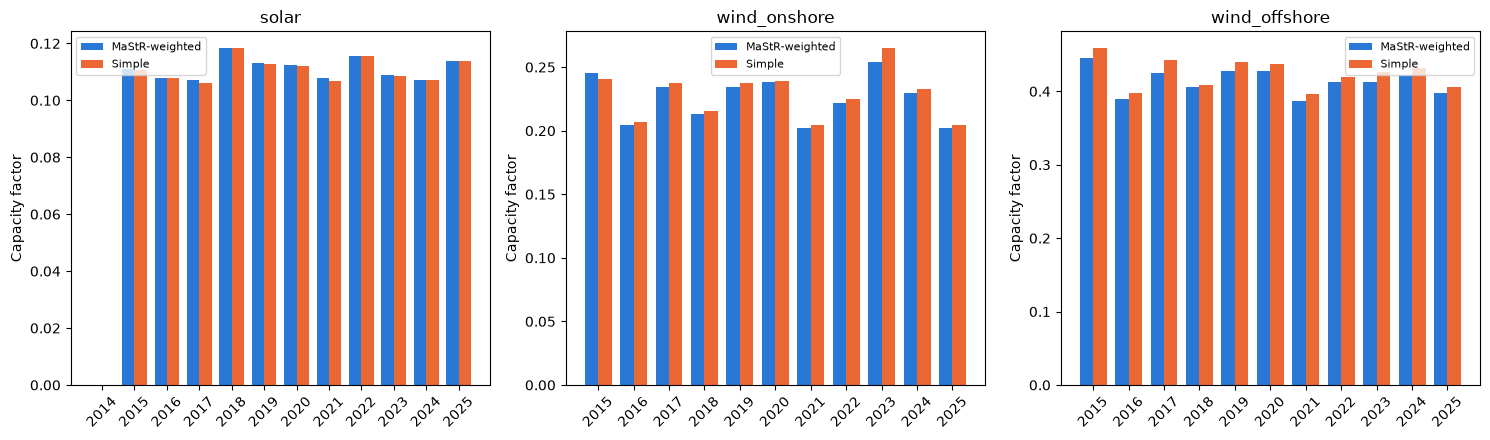

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (tech, (simple, complex_)) in zip(axes, SERIES.items()):
    df = pd.concat([simple.rename("simple"), complex_.rename("complex")], axis=1, sort=False).dropna()
    annual = df.groupby(df.index.year).mean()
    x = np.arange(len(annual))
    width = 0.38
    ax.bar(x - width / 2, annual["complex"], width, label="MaStR-weighted", color=COMPLEX_COLOR)
    ax.bar(x + width / 2, annual["simple"], width, label="Simple", color=SIMPLE_COLOR)
    ax.set_xticks(x)
    ax.set_xticklabels(annual.index, rotation=45)
    ax.set_ylabel("Capacity factor")
    ax.set_title(tech)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Takeaways

- **Solar matches almost perfectly**: correlation ~0.999, bias well under
  half a percentage point. A fixed, publicly sourced rooftop/ground and
  fixed/tracking mix captures essentially all of what MaStR's real
  installed-capacity mix would add -- the extra precision from unit-level
  data barely moves the national aggregate.
- **Wind onshore is decent but not much better than doing nothing clever**:
  correlation ~0.975, bias ~+0.3 percentage points -- close to, not
  meaningfully better than, the already-existing naive equal-zone mean
  (`pecd_wind_onshore_country_capacity_factor`). Germany's 7 PEON zones
  don't differ enough in area for area-weighting to add much over equal
  weighting.
- **Wind offshore matches well once the all-NaN zones are handled
  correctly**: correlation ~0.977, bias ~+1 percentage point. The first
  attempt at this (not shown) got a ~20% *relative* bias by summing
  zone-weight x capacity-factor with pandas' default NaN skipping --
  silently dropping ~23% of the area weight (the 3 unmodeled PEOF zones)
  without redistributing it, rather than a real property of offshore
  siting. Renormalizing over only the modeled zones fixes essentially all
  of the gap.
- **Net**: for a first-cut, MaStR-free capacity factor -- e.g. to eventually
  extend beyond Germany to every PECD country -- fixed technology-mix
  weights (solar) and area-weighted, NaN-aware zone means (wind) already
  get remarkably close to the fully fleet-weighted version for Germany,
  the one country where a true comparison is possible.